In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/shopping_trends.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [3]:
features = df[[
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]].copy()

In [4]:
frequency_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

features["Purchase Frequency"] = (
    df["Frequency of Purchases"].map(frequency_map)
)

In [5]:
features["Is_Subscribed"] = df["Subscription Status"].map({
    "Yes": 1,
    "No": 0
})

features["Discount_Applied"] = df["Discount Applied"].map({
    "Yes": 1,
    "No": 0
})

features["Promo_Used"] = df["Promo Code Used"].map({
    "Yes": 1,
    "No": 0
})

In [6]:
features.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used
0,55,53,3.1,14,26,1,1,1
1,19,64,3.1,2,26,1,1,1
2,50,73,3.1,23,52,1,1,1
3,21,90,3.5,49,52,1,1,1
4,45,49,2.7,31,1,1,1,1


In [7]:
features.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538,17.471282,0.270000,0.430000,0.430000
std,15.207589,23.685392,0.716223,14.447125,16.809646,0.444016,0.495139,0.495139
min,18.000000,20.000000,2.500000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,31.000000,39.000000,3.100000,13.000000,4.000000,0.000000,0.000000,0.000000
50%,44.000000,60.000000,3.700000,25.000000,12.000000,0.000000,0.000000,0.000000
75%,57.000000,81.000000,4.400000,38.000000,26.000000,1.000000,1.000000,1.000000
max,70.000000,100.000000,5.000000,50.000000,52.000000,1.000000,1.000000,1.000000


In [8]:
features["Estimated_Annual_Spend"] = (
    features["Purchase Amount (USD)"]
    * features["Purchase Frequency"]
)

In [9]:
features["Purchase_Engagement"] = (
    features["Previous Purchases"]
    * features["Purchase Frequency"]
)

In [10]:
features["Promotion_Engagement"] = (
    features["Discount_Applied"]
    + features["Promo_Used"]
    + features["Is_Subscribed"]
)

In [11]:
features[
    [
        "Estimated_Annual_Spend",
        "Purchase_Engagement",
        "Promotion_Engagement"
    ]
].describe()

,Estimated_Annual_Spend,Purchase_Engagement,Promotion_Engagement
count,3900.000000,3900.000000,3900.000000
mean,1038.930513,443.992051,1.130000
std,1145.034309,555.532978,1.339239
min,20.000000,1.000000,0.000000
25%,188.000000,56.000000,0.000000
50%,572.000000,183.000000,0.000000
75%,1638.000000,624.000000,3.000000
max,5200.000000,2600.000000,3.000000


In [12]:
features.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used,Estimated_Annual_Spend,Purchase_Engagement,Promotion_Engagement
0,55,53,3.1,14,26,1,1,1,1378,364,3
1,19,64,3.1,2,26,1,1,1,1664,52,3
2,50,73,3.1,23,52,1,1,1,3796,1196,3
3,21,90,3.5,49,52,1,1,1,4680,2548,3
4,45,49,2.7,31,1,1,1,1,49,31,3


In [13]:
features.corr().round(2)

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used,Estimated_Annual_Spend,Purchase_Engagement,Promotion_Engagement
Age,1.00,-0.01,-0.02,0.04,-0.00,0.01,0.00,0.00,-0.01,0.03,0.01
Purchase Amount (USD),-0.01,1.00,0.03,0.01,-0.01,-0.01,-0.02,-0.02,0.35,-0.01,-0.02
Review Rating,-0.02,0.03,1.00,0.00,-0.00,-0.01,-0.01,-0.01,0.00,0.01,-0.01
Previous Purchases,0.04,0.01,0.00,1.00,0.00,0.03,0.02,0.02,0.01,0.46,0.03
Purchase Frequency,-0.00,-0.01,-0.00,0.00,1.00,0.02,0.00,0.00,0.87,0.78,0.01
Is_Subscribed,0.01,-0.01,-0.01,0.03,0.02,1.00,0.70,0.70,0.01,0.03,0.85
Discount_Applied,0.00,-0.02,-0.01,0.02,0.00,0.70,1.00,1.00,-0.00,0.02,0.97
Promo_Used,0.00,-0.02,-0.01,0.02,0.00,0.70,1.00,1.00,-0.00,0.02,0.97
Estimated_Annual_Spend,-0.01,0.35,0.00,0.01,0.87,0.01,-0.00,-0.00,1.00,0.68,0.00
Purchase_Engagement,0.03,-0.01,0.01,0.46,0.78,0.03,0.02,0.02,0.68,1.00,0.03


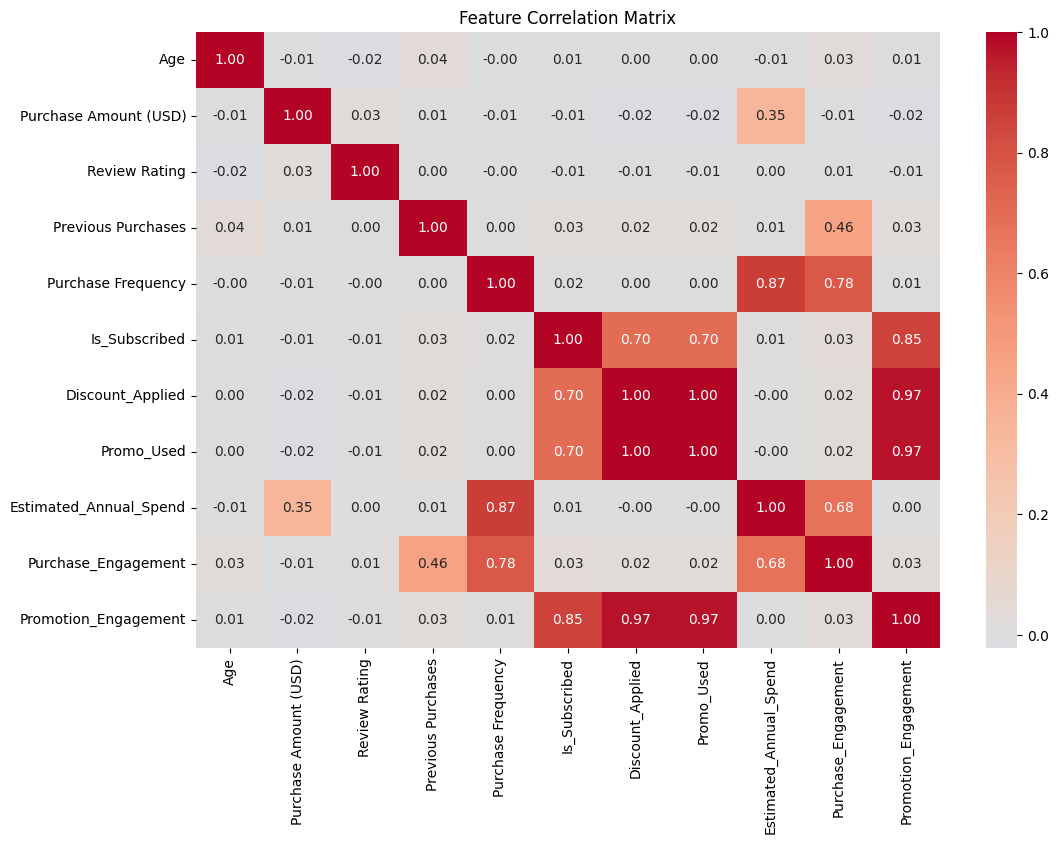

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
selected_features = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "Purchase Frequency",
    "Is_Subscribed",
    "Estimated_Annual_Spend",
    "Purchase_Engagement"
]

features_selected = features[selected_features].copy()

features_selected.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Estimated_Annual_Spend,Purchase_Engagement
0,55,53,3.1,14,26,1,1378,364
1,19,64,3.1,2,26,1,1664,52
2,50,73,3.1,23,52,1,3796,1196
3,21,90,3.5,49,52,1,4680,2548
4,45,49,2.7,31,1,1,49,31


In [18]:
features_selected.shape

(3900, 8)

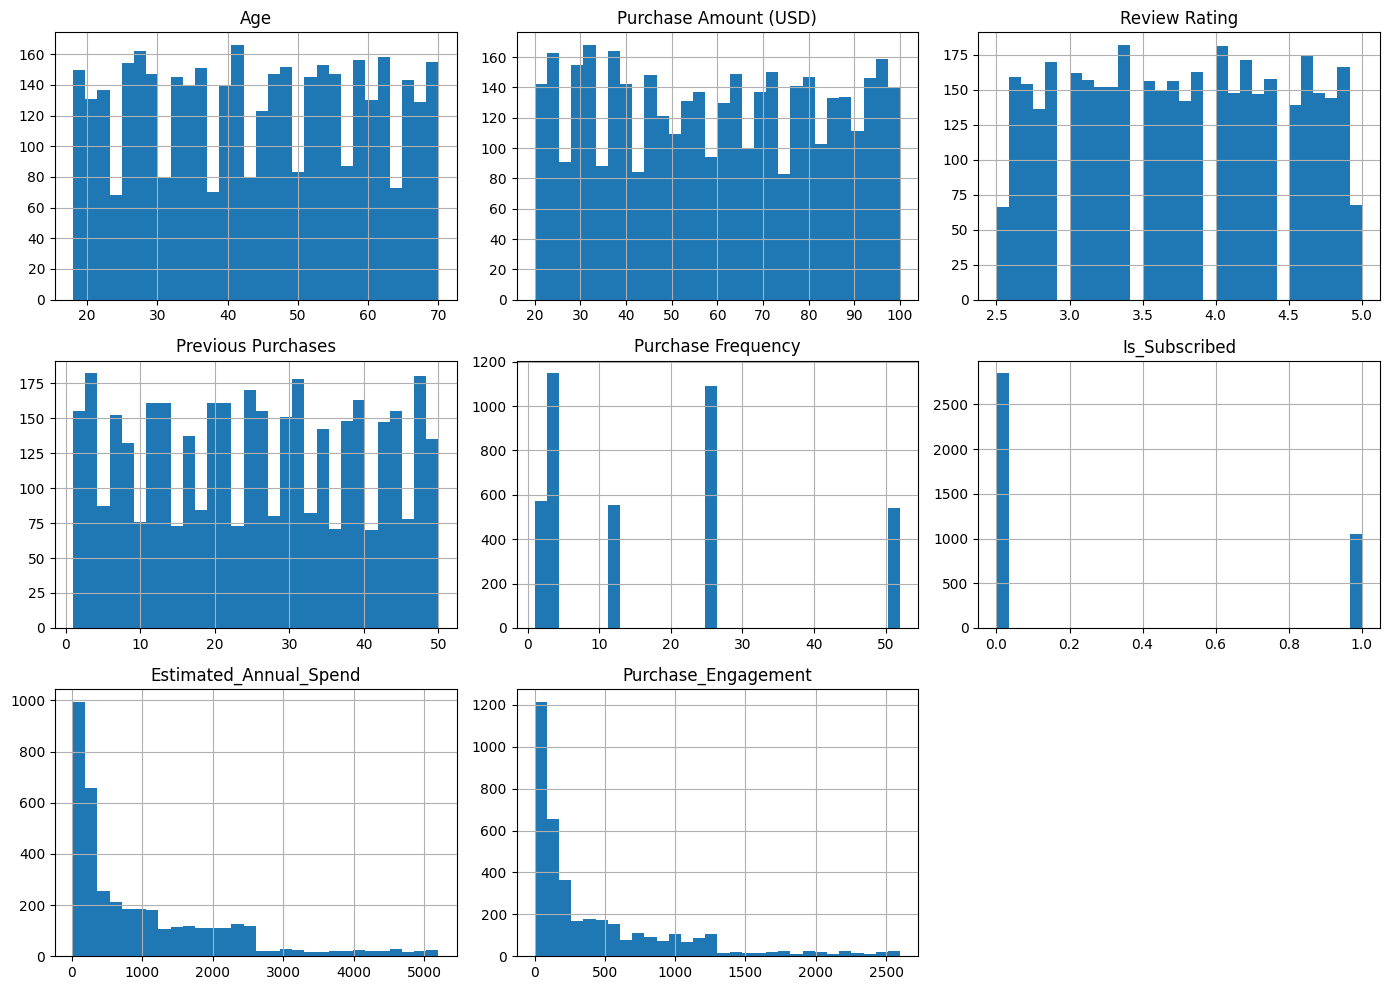

In [19]:
features_selected.hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [20]:
features_selected[
    [
        "Purchase Amount (USD)",
        "Previous Purchases",
        "Purchase Frequency",
        "Estimated_Annual_Spend",
        "Purchase_Engagement"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0
Purchase Frequency,3900.0,17.471282,16.809646,1.0,4.0,12.0,26.0,52.0
Estimated_Annual_Spend,3900.0,1038.930513,1145.034309,20.0,188.0,572.0,1638.0,5200.0
Purchase_Engagement,3900.0,443.992051,555.532978,1.0,56.0,183.0,624.0,2600.0


In [21]:
features_selected["Log_Annual_Spend"] = np.log1p(
    features_selected["Estimated_Annual_Spend"]
)

features_selected["Log_Purchase_Engagement"] = np.log1p(
    features_selected["Purchase_Engagement"]
)

In [22]:
features_selected[
    [
        "Estimated_Annual_Spend",
        "Log_Annual_Spend",
        "Purchase_Engagement",
        "Log_Purchase_Engagement"
    ]
].describe().round(2)

,Estimated_Annual_Spend,Log_Annual_Spend,Purchase_Engagement,Log_Purchase_Engagement
count,3900.00,3900.00,3900.00,3900.00
mean,1038.93,6.22,443.99,5.19
std,1145.03,1.35,555.53,1.53
min,20.00,3.04,1.00,0.69
25%,188.00,5.24,56.00,4.04
50%,572.00,6.35,183.00,5.21
75%,1638.00,7.40,624.00,6.44
max,5200.00,8.56,2600.00,7.86


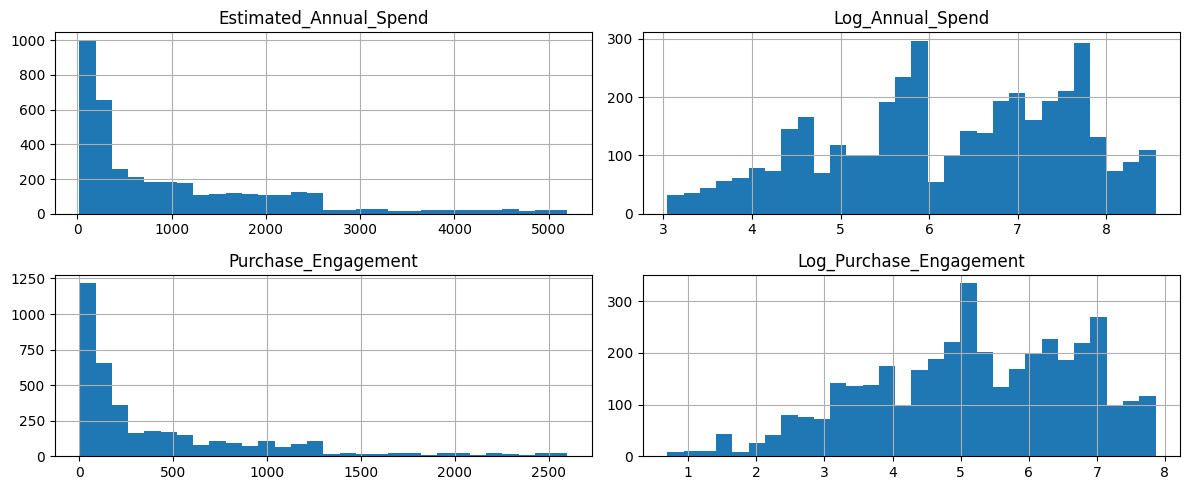

In [23]:
features_selected[
    [
        "Estimated_Annual_Spend",
        "Log_Annual_Spend",
        "Purchase_Engagement",
        "Log_Purchase_Engagement"
    ]
].hist(figsize=(12, 5), bins=30)

plt.tight_layout()
plt.show()

In [24]:
final_features = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "Purchase Frequency",
    "Is_Subscribed",
    "Log_Annual_Spend",
    "Log_Purchase_Engagement"
]

X = features_selected[final_features].copy()
X.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Log_Annual_Spend,Log_Purchase_Engagement
0,55,53,3.1,14,26,1,7.229114,5.899897
1,19,64,3.1,2,26,1,7.417580,3.970292
2,50,73,3.1,23,52,1,8.241967,7.087574
3,21,90,3.5,49,52,1,8.451267,7.843456
4,45,49,2.7,31,1,1,3.912023,3.465736


In [25]:
X.shape

(3900, 8)

# Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(3900, 8)

In [27]:
X_scaled.mean(axis=0)
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)

results_df

C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Program Files\Python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python38\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python38\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


,k,inertia,silhouette
0,2,23720.333058,0.212326
1,3,21525.161305,0.185282
2,4,19725.448227,0.157725
3,5,18247.142155,0.162031
4,6,17013.167667,0.160424
5,7,16164.916030,0.150017
6,8,15499.376858,0.143131
7,9,14930.770360,0.140325
8,10,14401.027067,0.144633


In [30]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_2 = kmeans_2.fit_predict(X_scaled)

profile = X.copy()
profile["Cluster"] = labels_2

profile.groupby("Cluster").mean().T

Cluster,0,1
Age,44.199396,43.932602
Purchase Amount (USD),58.439577,61.138976
Review Rating,3.745871,3.754180
Previous Purchases,23.891239,26.866771
Purchase Frequency,4.366566,31.068966
Is_Subscribed,0.263847,0.276385
Log_Annual_Spend,5.122712,7.356585
Log_Purchase_Engagement,4.038541,6.392698


In [31]:
profile["Cluster"].value_counts().sort_index()

Cluster
0    1986
1    1914
Name: count, dtype: int64

In [32]:
cluster_means = profile.groupby("Cluster").mean()

cluster_means

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Log_Annual_Spend,Log_Purchase_Engagement
Cluster,,,,,,,,
0,44.199396,58.439577,3.745871,23.891239,4.366566,0.263847,5.122712,4.038541
1,43.932602,61.138976,3.754180,26.866771,31.068966,0.276385,7.356585,6.392698


In [33]:
validation_features = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "Purchase Frequency",
    "Is_Subscribed"
]

X_validation = features_selected[validation_features].copy()

scaler_validation = StandardScaler()

X_validation_scaled = scaler_validation.fit_transform(X_validation)

validation_results = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_validation_scaled)

    validation_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(
            X_validation_scaled,
            labels
        )
    })

pd.DataFrame(validation_results)

,k,inertia,silhouette
0,2,19494.580736,0.207116
1,3,17308.289765,0.156308
2,4,15528.186120,0.167813
3,5,14343.612249,0.151974
4,6,13404.538840,0.149732


# Gaussien Mixture Model

In [34]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

gmm_results = []

for k in range(2, 7):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(X_scaled)

    gmm_results.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "AIC": gmm.aic(X_scaled),
        "BIC": gmm.bic(X_scaled)
    })

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df

,k,silhouette,AIC,BIC
0,2,0.209218,60010.740000,60568.657133
1,3,0.147437,55303.827125,56143.837191
2,4,0.156376,22069.630177,23191.733175
3,5,0.102934,2293.066630,3697.262560
4,6,0.139620,-7.763800,1678.525062


# DBSCAN

In [36]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

db_labels = dbscan.fit_predict(X_scaled)

pd.Series(db_labels).value_counts().sort_index()

-1     2555
 0      524
 1      556
 2       10
 3       45
 4       45
 5       24
 6       18
 7       10
 8       25
 9       10
 10       8
 11      15
 12      13
 13      12
 14      11
 15      10
 16       9
Name: count, dtype: int64

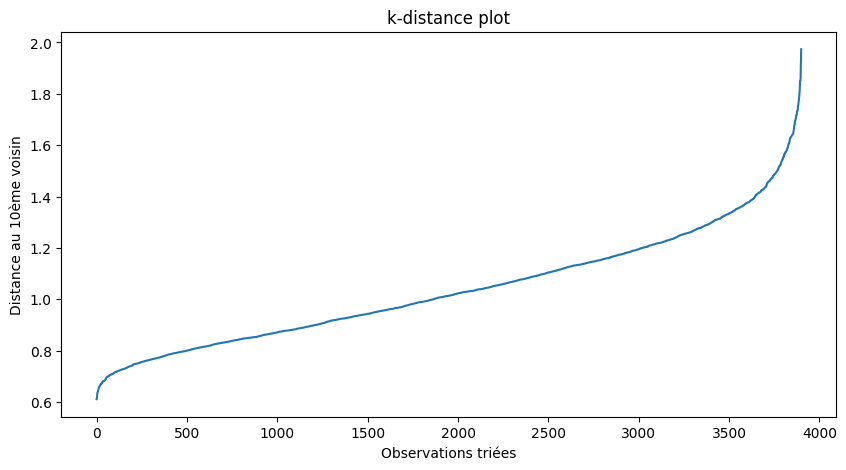

In [37]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Observations triées")
plt.ylabel("Distance au 10ème voisin")
plt.title("k-distance plot")

plt.show()

In [38]:
dbscan = DBSCAN(
    eps=1.4,
    min_samples=10
)

db_labels = dbscan.fit_predict(X_scaled)

cluster_counts = pd.Series(db_labels).value_counts().sort_index()

cluster_counts

-1      26
 0     886
 1     144
 2    2465
 3     379
Name: count, dtype: int64

In [39]:
noise_ratio = (db_labels == -1).mean()

print(f"Noise ratio: {noise_ratio:.2%}")

Noise ratio: 0.67%


In [40]:
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 4


In [41]:
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        db_labels[mask]
    )
    print("Silhouette:", dbscan_silhouette)
else:
    print("Not enough clusters to calculate silhouette.")

Silhouette: 0.1273318543169205


# PCA

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(3900, 2)

In [43]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.33067167 0.15022297]
Total explained variance: 0.48089463644405706


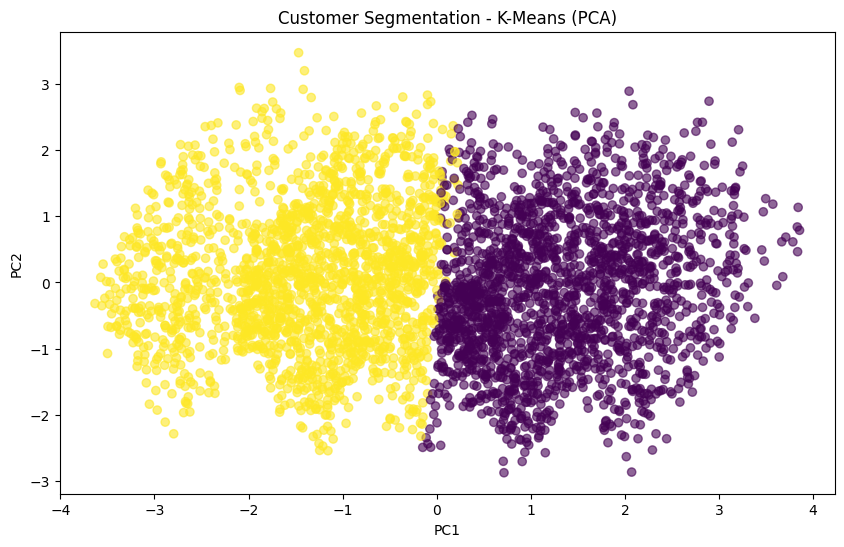

In [45]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_2,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation - K-Means (PCA)")
plt.show()

In [46]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=final_features
)

loadings

,PC1,PC2
Age,-0.002243,-0.222818
Purchase Amount (USD),-0.101783,0.451880
Review Rating,-0.000509,0.096515
Previous Purchases,-0.187744,-0.730024
Purchase Frequency,-0.546967,0.155917
Is_Subscribed,-0.021704,-0.154146
Log_Annual_Spend,-0.570639,0.288102
Log_Purchase_Engagement,-0.573685,-0.269875


In [47]:
loadings.sort_values("PC1", key=abs, ascending=False)

,PC1,PC2
Log_Purchase_Engagement,-0.573685,-0.269875
Log_Annual_Spend,-0.570639,0.288102
Purchase Frequency,-0.546967,0.155917
Previous Purchases,-0.187744,-0.730024
Purchase Amount (USD),-0.101783,0.451880
Is_Subscribed,-0.021704,-0.154146
Age,-0.002243,-0.222818
Review Rating,-0.000509,0.096515


# Clusters'Profiling 

In [48]:
profile = features_selected.copy()
profile["Cluster"] = labels_2

cluster_profile = profile.groupby("Cluster").mean().T

cluster_profile

Cluster,0,1
Age,44.199396,43.932602
Purchase Amount (USD),58.439577,61.138976
Review Rating,3.745871,3.754180
Previous Purchases,23.891239,26.866771
Purchase Frequency,4.366566,31.068966
Is_Subscribed,0.263847,0.276385
Estimated_Annual_Spend,238.940081,1869.014629
Purchase_Engagement,89.548338,811.769070
Log_Annual_Spend,5.122712,7.356585
Log_Purchase_Engagement,4.038541,6.392698


In [49]:
profile["Cluster"].value_counts().sort_index()

Cluster
0    1986
1    1914
Name: count, dtype: int64

In [50]:
cluster_size = profile["Cluster"].value_counts().sort_index()

cluster_size_pct = (
    cluster_size / len(profile) * 100
).round(2)

cluster_size_pct

Cluster
0    50.92
1    49.08
Name: count, dtype: float64

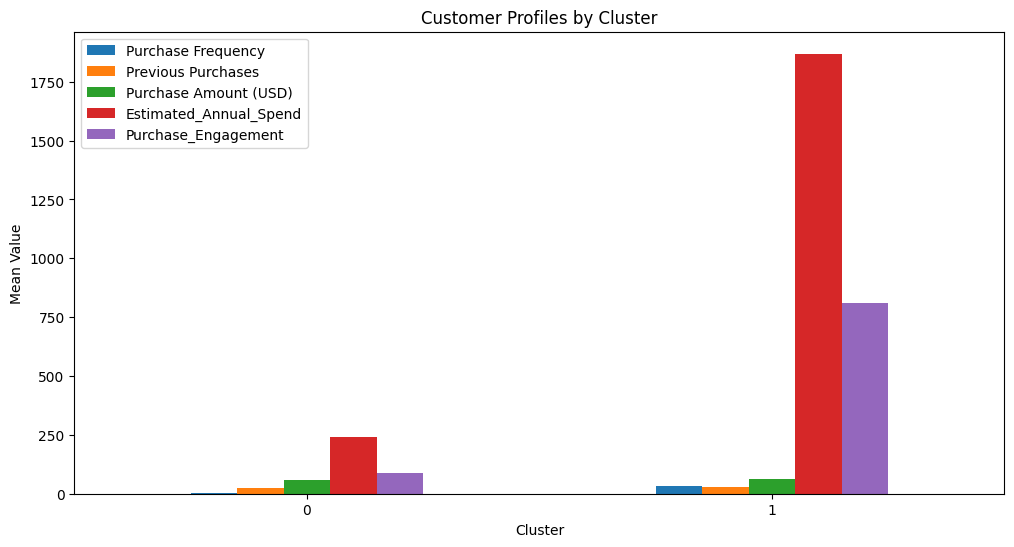

In [51]:
profile.groupby("Cluster")[
    [
        "Purchase Frequency",
        "Previous Purchases",
        "Purchase Amount (USD)",
        "Estimated_Annual_Spend",
        "Purchase_Engagement"
    ]
].mean().plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Customer Profiles by Cluster")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.show()

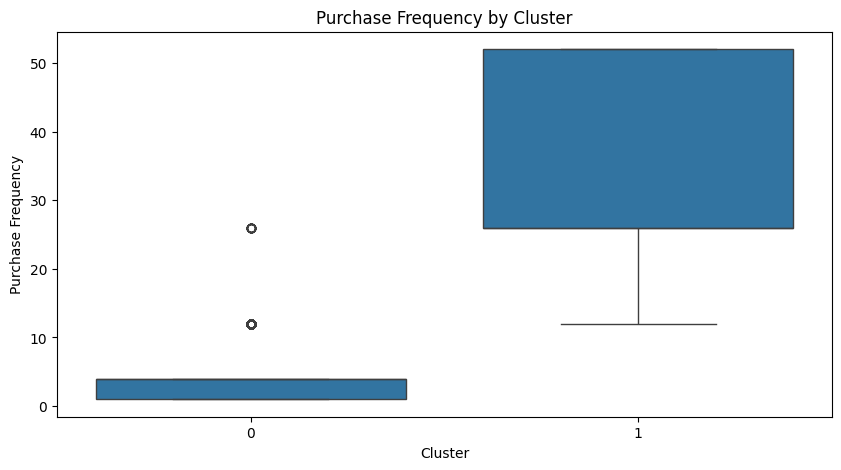

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=profile,
    x="Cluster",
    y="Purchase Frequency"
)

plt.title("Purchase Frequency by Cluster")
plt.show()

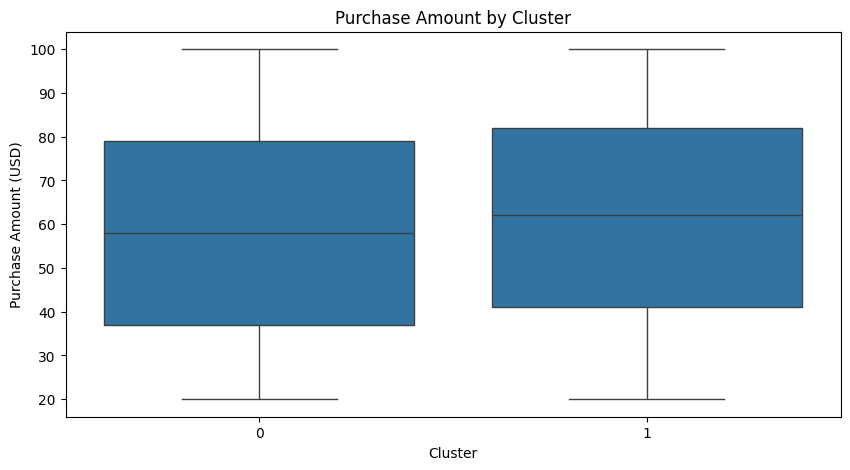

In [53]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=profile,
    x="Cluster",
    y="Purchase Amount (USD)"
)

plt.title("Purchase Amount by Cluster")
plt.show()

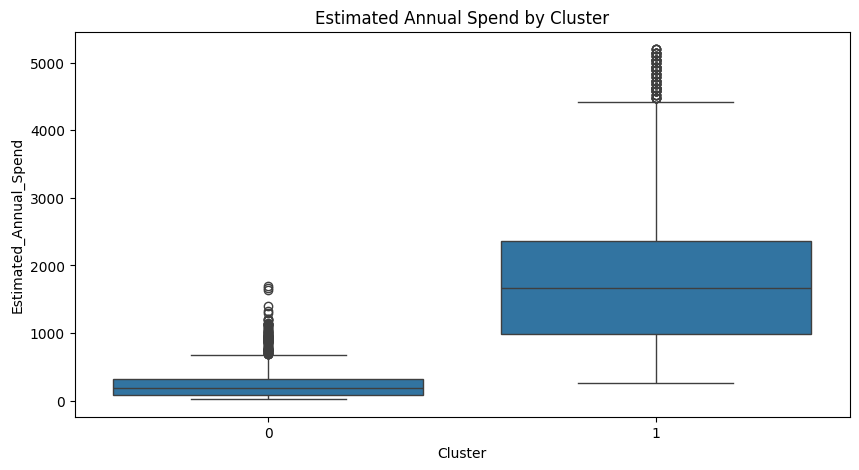

In [54]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=profile,
    x="Cluster",
    y="Estimated_Annual_Spend"
)

plt.title("Estimated Annual Spend by Cluster")
plt.show()

Le clustering identifie principalement deux groupes différenciés par leur fréquence d'achat. Les montants moyens par transaction restent relativement similaires entre les groupes. La différence de dépense annuelle estimée découle donc principalement de la fréquence d'achat plutôt que d'une différence importante de valeur par transaction.

# Analyse des variables catégorielles par cluster

In [55]:
pd.crosstab(
    profile["Cluster"],
    df["Category"],
    normalize="index"
).round(3) * 100

Category,Accessories,Clothing,Footwear,Outerwear
Cluster,,,,
0,31.8,44.8,15.2,8.3
1,31.8,44.3,15.6,8.4


In [56]:
pd.crosstab(
    profile["Cluster"],
    df["Gender"],
    normalize="index"
).round(3) * 100

Gender,Female,Male
Cluster,,
0,31.5,68.5
1,32.5,67.5


In [57]:
pd.crosstab(
    profile["Cluster"],
    df["Subscription Status"],
    normalize="index"
).round(3) * 100

Subscription Status,No,Yes
Cluster,,
0,73.6,26.4
1,72.4,27.6


In [58]:
pd.crosstab(
    profile["Cluster"],
    df["Discount Applied"],
    normalize="index"
).round(3) * 100

Discount Applied,No,Yes
Cluster,,
0,56.8,43.2
1,57.2,42.8


In [59]:
pd.crosstab(
    profile["Cluster"],
    df["Promo Code Used"],
    normalize="index"
).round(3) * 100

Promo Code Used,No,Yes
Cluster,,
0,56.8,43.2
1,57.2,42.8


In [60]:
pd.crosstab(
    profile["Cluster"],
    df["Season"],
    normalize="index"
).round(3) * 100

Season,Fall,Spring,Summer,Winter
Cluster,,,,
0,25.9,25.5,25.0,23.7
1,24.1,25.8,24.0,26.2


In [61]:
pd.crosstab(
    profile["Cluster"],
    df["Payment Method"],
    normalize="index"
).round(3) * 100

Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Cluster,,,,,,
0,16.1,17.6,17.4,16.6,16.3,16.1
1,16.3,15.6,18.3,15.9,16.5,17.5


In [62]:
pd.crosstab(
    profile["Cluster"],
    df["Shipping Type"],
    normalize="index"
).round(3) * 100

Shipping Type,2-Day Shipping,Express,Free Shipping,Next Day Air,Standard,Store Pickup
Cluster,,,,,,
0,15.9,16.1,18.1,16.5,16.5,17.0
1,16.3,17.1,16.5,16.8,17.1,16.3


Les deux clusters présentent des distributions catégorielles très similaires. La segmentation est donc principalement portée par les variables quantitatives liées à la fréquence et à l'intensité d'achat, plutôt que par les caractéristiques démographiques, les catégories de produits ou les comportements promotionnels

Cluster 0 — lower-frequency

~50.9% des clients
fréquence moyenne ≈ 4.37/an
achats précédents ≈ 23.9
montant ≈ 58.4$

Cluster 1 — higher-frequency

~49.1% des clients
fréquence moyenne ≈ 31.07/an
achats précédents ≈ 26.9
montant ≈ 61.1$

La différence majeure est donc la fréquence, pas le montant par achat.

In [63]:
# Export des features finales pour les étapes suivantes

X.to_csv("../data/clustering_features.csv", index=False)
np.save("../data/X_scaled.npy", X_scaled)

print("Features exported:", X.shape)
print("Scaled matrix exported:", X_scaled.shape)

Features exported: (3900, 8)
Scaled matrix exported: (3900, 8)
